In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os

from sklearn.model_selection import (
    StratifiedKFold,
    cross_val_score,
    GridSearchCV,
    RandomizedSearchCV
)

from sklearn.pipeline import Pipeline

from sklearn.tree import DecisionTreeClassifier

from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier
)

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    RocCurveDisplay
)

In [2]:
train_df = pd.read_csv("../outputs/train_data.csv")

test_df = pd.read_csv("../outputs/test_data.csv")

X_train = train_df.drop("Revenue", axis=1)

y_train = train_df["Revenue"]

X_test = test_df.drop("Revenue", axis=1)

y_test = test_df["Revenue"]

print("Data loaded successfully.")

print(f"Training Data: {X_train.shape}")
print(f"Testing Data: {X_test.shape}")

Data loaded successfully.
Training Data: (9764, 21)
Testing Data: (2441, 21)


In [3]:
preprocessor = joblib.load(
    "../outputs/preprocessor.pkl"
)

print("Preprocessor loaded.")

Preprocessor loaded.


In [4]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

print("5-Fold Stratified Cross Validation configured.")

5-Fold Stratified Cross Validation configured.


In [5]:
model_files = {
    "Logistic Regression": "../outputs/logistic_regression_model.pkl",
    "Decision Tree": "../outputs/decision_tree_model.pkl",
    "Random Forest": "../outputs/random_forest_model.pkl",
    "Gradient Boosting": "../outputs/gradient_boosting_model.pkl"
}

loaded_models = {}

for name, path in model_files.items():
    
    loaded_models[name] = joblib.load(path)

print("All models loaded successfully.")

All models loaded successfully.


In [6]:
cv_results = []

for model_name, model in loaded_models.items():
    
    print(f"Running Cross Validation: {model_name}")
    
    scores = cross_val_score(
        model,
        X_train,
        y_train,
        cv=cv,
        scoring="roc_auc",
        n_jobs=-1
    )
    
    cv_results.append({
        "Model": model_name,
        "Fold 1": scores[0],
        "Fold 2": scores[1],
        "Fold 3": scores[2],
        "Fold 4": scores[3],
        "Fold 5": scores[4],
        "Mean ROC-AUC": scores.mean(),
        "Standard Deviation": scores.std()
    })

Running Cross Validation: Logistic Regression
Running Cross Validation: Decision Tree
Running Cross Validation: Random Forest
Running Cross Validation: Gradient Boosting


In [7]:
cv_results_df = pd.DataFrame(cv_results)

cv_results_df = cv_results_df.sort_values(
    by="Mean ROC-AUC",
    ascending=False
).reset_index(drop=True)

cv_results_df

,Model,Fold 1,Fold 2,Fold 3,Fold 4,Fold 5,Mean ROC-AUC,Standard Deviation
0,Gradient Boosting,0.927237,0.921660,0.927731,0.939288,0.930647,0.929312,0.005773
1,Random Forest,0.922094,0.920717,0.928442,0.930425,0.921248,0.924585,0.004032
2,Logistic Regression,0.893143,0.862655,0.898319,0.896192,0.898193,0.889701,0.013652
3,Decision Tree,0.876688,0.872425,0.889063,0.901808,0.877191,0.883435,0.010724


In [8]:
cv_results_df.to_csv(
    "../outputs/cross_validation_results.csv",
    index=False
)

print("Cross Validation results saved.")

Cross Validation results saved.


In [9]:
decision_tree_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        
        (
            "model",
            DecisionTreeClassifier(
                random_state=42
            )
        )
    ]
)

dt_param_grid = {
    "model__max_depth": [4, 6, 8, 10],
    
    "model__min_samples_split": [
        2, 5, 10, 20
    ],
    
    "model__min_samples_leaf": [
        1, 2, 5, 10
    ]
}

grid_search = GridSearchCV(
    estimator=decision_tree_pipeline,
    param_grid=dt_param_grid,
    scoring="roc_auc",
    cv=cv,
    n_jobs=-1
)

print("GridSearchCV configured.")

GridSearchCV configured.


In [10]:
grid_search.fit(
    X_train,
    y_train
)

print("GridSearchCV completed.")

print("\nBest Parameters:")
print(grid_search.best_params_)

print(
    f"\nBest Cross Validation ROC-AUC: "
    f"{grid_search.best_score_:.4f}"
)

GridSearchCV completed.

Best Parameters:
{'model__max_depth': 4, 'model__min_samples_leaf': 10, 'model__min_samples_split': 2}

Best Cross Validation ROC-AUC: 0.9142


In [11]:
random_forest_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        
        (
            "model",
            RandomForestClassifier(
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

rf_param_distribution = {
    
    "model__n_estimators": [
        100, 200, 300, 400
    ],
    
    "model__max_depth": [
        6, 8, 10, 12, None
    ],
    
    "model__min_samples_split": [
        2, 5, 10
    ],
    
    "model__min_samples_leaf": [
        1, 2, 4
    ],
    
    "model__max_features": [
        "sqrt",
        "log2"
    ]
}

In [12]:
random_search = RandomizedSearchCV(
    
    estimator=random_forest_pipeline,
    
    param_distributions=rf_param_distribution,
    
    n_iter=20,
    
    scoring="roc_auc",
    
    cv=cv,
    
    random_state=42,
    
    n_jobs=-1
)

print("RandomizedSearchCV configured.")

RandomizedSearchCV configured.


In [13]:
random_search.fit(
    X_train,
    y_train
)

print("RandomizedSearchCV completed.")

print("\nBest Parameters:")
print(random_search.best_params_)

print(
    f"\nBest Cross Validation ROC-AUC: "
    f"{random_search.best_score_:.4f}"
)

RandomizedSearchCV completed.

Best Parameters:
{'model__n_estimators': 300, 'model__min_samples_split': 5, 'model__min_samples_leaf': 4, 'model__max_features': 'log2', 'model__max_depth': None}

Best Cross Validation ROC-AUC: 0.9250


In [14]:
tuning_results = pd.DataFrame({
    
    "Model": [
        "Decision Tree",
        "Random Forest"
    ],
    
    "Tuning Method": [
        "GridSearchCV",
        "RandomizedSearchCV"
    ],
    
    "Best CV ROC-AUC": [
        grid_search.best_score_,
        random_search.best_score_
    ],
    
    "Best Parameters": [
        str(grid_search.best_params_),
        str(random_search.best_params_)
    ]
})

tuning_results

,Model,Tuning Method,Best CV ROC-AUC,Best Parameters
0,Decision Tree,GridSearchCV,0.914204,"{'model__max_depth': 4, 'model__min_samples_le..."
1,Random Forest,RandomizedSearchCV,0.925033,"{'model__n_estimators': 300, 'model__min_sampl..."


In [15]:
tuned_models = {
    
    "Decision Tree Tuned":
    grid_search.best_estimator_,
    
    "Random Forest Tuned":
    random_search.best_estimator_
}

In [16]:
final_results = []

all_final_models = {
    **loaded_models,
    **tuned_models
}

for model_name, model in all_final_models.items():
    
    predictions = model.predict(X_test)
    
    probabilities = model.predict_proba(X_test)[:, 1]
    
    accuracy = accuracy_score(
        y_test,
        predictions
    )
    
    precision = precision_score(
        y_test,
        predictions,
        zero_division=0
    )
    
    recall = recall_score(
        y_test,
        predictions,
        zero_division=0
    )
    
    f1 = f1_score(
        y_test,
        predictions,
        zero_division=0
    )
    
    roc_auc = roc_auc_score(
        y_test,
        probabilities
    )
    
    final_results.append({
        
        "Model": model_name,
        
        "Accuracy": accuracy,
        
        "Precision": precision,
        
        "Recall": recall,
        
        "F1 Score": f1,
        
        "ROC-AUC": roc_auc
    })

In [17]:
final_results_df = pd.DataFrame(final_results)

final_results_df = final_results_df.sort_values(
    by="ROC-AUC",
    ascending=False
).reset_index(drop=True)

final_results_df

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Gradient Boosting,0.906186,0.720461,0.654450,0.685871,0.935737
1,Random Forest Tuned,0.905776,0.758503,0.583770,0.659763,0.928488
2,Random Forest,0.904957,0.756849,0.578534,0.655786,0.927721
3,Decision Tree Tuned,0.902089,0.758123,0.549738,0.637329,0.920083
4,Logistic Regression,0.888570,0.754630,0.426702,0.545151,0.902461
5,Decision Tree,0.896354,0.708738,0.573298,0.633864,0.880333


In [18]:
final_results_df.insert(
    0,
    "Rank",
    range(1, len(final_results_df) + 1)
)

final_results_df

,Rank,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,1,Gradient Boosting,0.906186,0.720461,0.654450,0.685871,0.935737
1,2,Random Forest Tuned,0.905776,0.758503,0.583770,0.659763,0.928488
2,3,Random Forest,0.904957,0.756849,0.578534,0.655786,0.927721
3,4,Decision Tree Tuned,0.902089,0.758123,0.549738,0.637329,0.920083
4,5,Logistic Regression,0.888570,0.754630,0.426702,0.545151,0.902461
5,6,Decision Tree,0.896354,0.708738,0.573298,0.633864,0.880333


In [19]:
final_results_df.to_csv(
    "../outputs/model_results.csv",
    index=False
)

print("Final model results saved successfully.")

Final model results saved successfully.


In [20]:
best_model_name = final_results_df.iloc[0]["Model"]

best_model_score = final_results_df.iloc[0]["ROC-AUC"]

print("=" * 60)

print("BEST MODEL SELECTION")

print("=" * 60)

print(f"\nBest Model: {best_model_name}")

print(
    f"Best ROC-AUC Score: "
    f"{best_model_score:.4f}"
)

BEST MODEL SELECTION

Best Model: Gradient Boosting
Best ROC-AUC Score: 0.9357


In [21]:
best_model = all_final_models[best_model_name]

joblib.dump(
    best_model,
    "../outputs/best_model.pkl"
)

print("Best model saved successfully.")

Best model saved successfully.


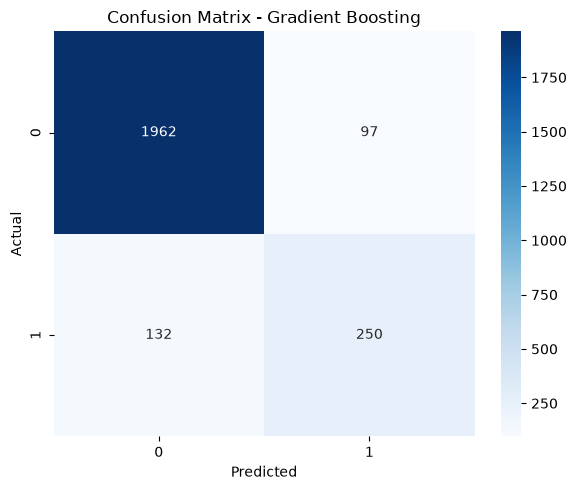

In [22]:
best_predictions = best_model.predict(X_test)

cm = confusion_matrix(
    y_test,
    best_predictions
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title(
    f"Confusion Matrix - {best_model_name}"
)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.tight_layout()

plt.savefig(
    "../outputs/figures/confusion_matrix.png",
    dpi=300
)

plt.show()

In [23]:
print(
    classification_report(
        y_test,
        best_predictions
    )
)

              precision    recall  f1-score   support

           0       0.94      0.95      0.94      2059
           1       0.72      0.65      0.69       382

    accuracy                           0.91      2441
   macro avg       0.83      0.80      0.82      2441
weighted avg       0.90      0.91      0.90      2441



<Figure size 800x600 with 0 Axes>

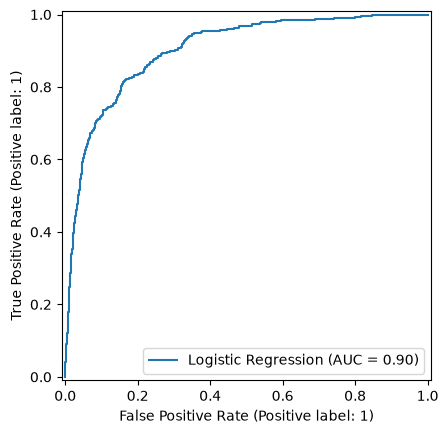

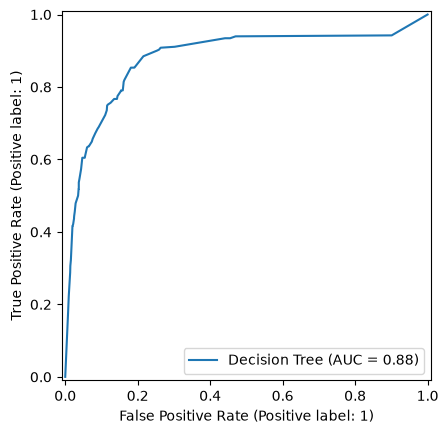

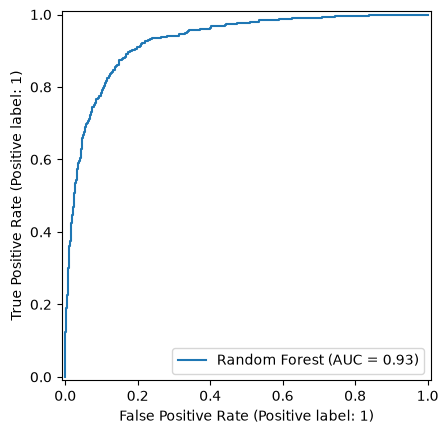

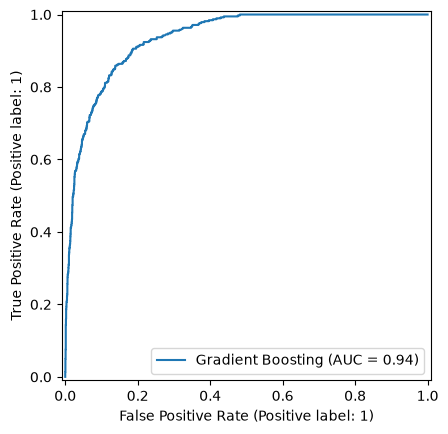

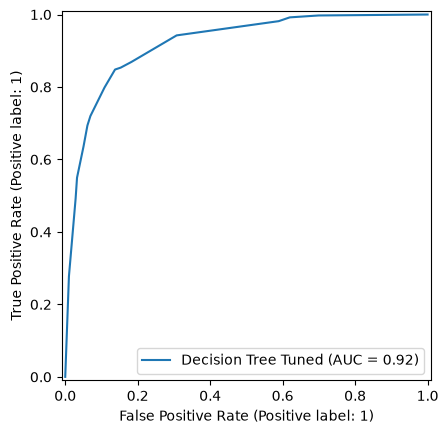

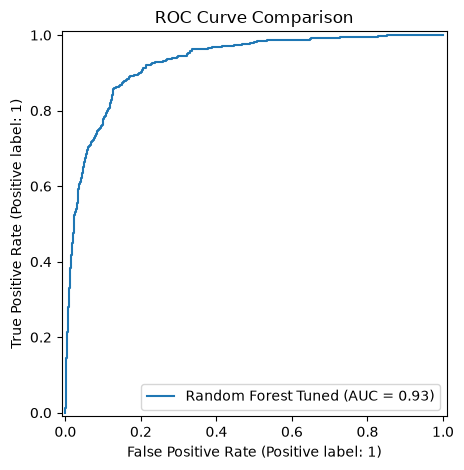

In [24]:
plt.figure(figsize=(8, 6))

for model_name, model in all_final_models.items():
    
    RocCurveDisplay.from_estimator(
        model,
        X_test,
        y_test,
        name=model_name
    )

plt.title("ROC Curve Comparison")

plt.tight_layout()

plt.savefig(
    "../outputs/figures/roc_curve_comparison.png",
    dpi=300
)

plt.show()

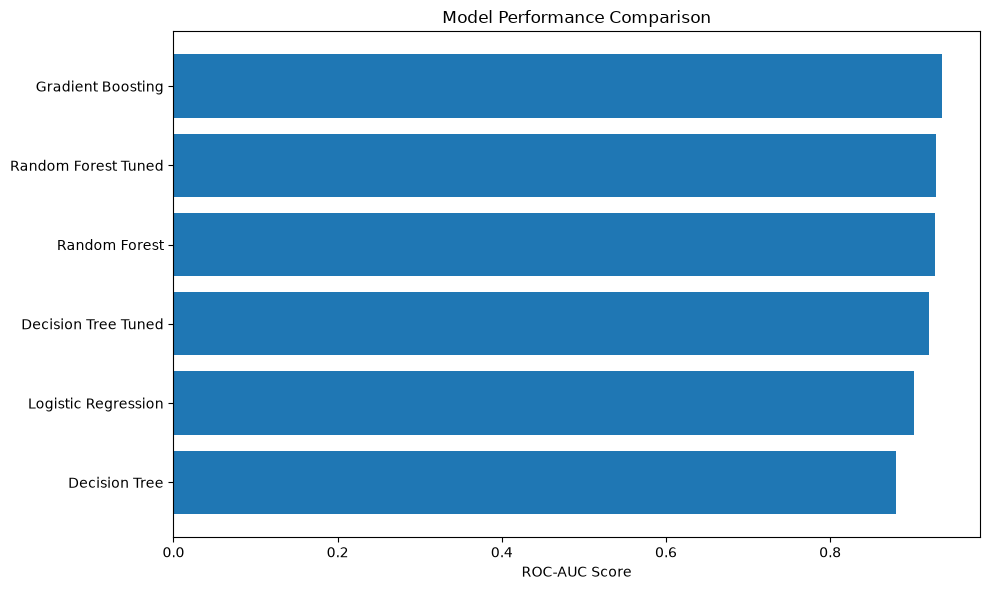

In [25]:
comparison_plot = final_results_df.copy()

comparison_plot = comparison_plot.sort_values(
    by="ROC-AUC"
)

plt.figure(figsize=(10, 6))

plt.barh(
    comparison_plot["Model"],
    comparison_plot["ROC-AUC"]
)

plt.xlabel("ROC-AUC Score")

plt.title("Model Performance Comparison")

plt.tight_layout()

plt.savefig(
    "../outputs/figures/model_comparison.png",
    dpi=300
)

plt.show()

In [26]:
print("=" * 70)

print("FINAL MODEL EVALUATION SUMMARY")

print("=" * 70)

best_row = final_results_df.iloc[0]

print(f"\nBest Model: {best_row['Model']}")

print(f"\nAccuracy: {best_row['Accuracy']:.2%}")

print(f"Precision: {best_row['Precision']:.2%}")

print(f"Recall: {best_row['Recall']:.2%}")

print(f"F1 Score: {best_row['F1 Score']:.2%}")

print(f"ROC-AUC: {best_row['ROC-AUC']:.2%}")

print("\nReason for Selection:")

print(
    "- Selected based on overall ROC-AUC performance"
)

print(
    "- Other classification metrics were also considered"
)

print(
    "- Cross-validation was used to verify model consistency"
)

print(
    "- Hyperparameter tuning was used to improve performance"
)

FINAL MODEL EVALUATION SUMMARY

Best Model: Gradient Boosting

Accuracy: 90.62%
Precision: 72.05%
Recall: 65.45%
F1 Score: 68.59%
ROC-AUC: 93.57%

Reason for Selection:
- Selected based on overall ROC-AUC performance
- Other classification metrics were also considered
- Cross-validation was used to verify model consistency
- Hyperparameter tuning was used to improve performance
